In [1]:
import pandas as pd

ethiopia = pd.read_csv("data/ethiopia_clean.csv")
kenya = pd.read_csv("data/kenya_clean.csv")
nigeria = pd.read_csv("data/nigeria_clean.csv")
sudan = pd.read_csv("data/sudan_clean.csv")
tanzania = pd.read_csv("data/tanzania_clean.csv")




In [2]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
nigeria["Country"] = "Nigeria"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"

In [21]:
df_all = pd.concat(
    [ethiopia, kenya, nigeria, sudan, tanzania],
    ignore_index=True
)

In [7]:
df_all.head()
df_all["Country"].value_counts()

Country
Ethiopia    4108
Kenya       4108
Nigeria     4108
Sudan       4108
Tanzania    4108
Name: count, dtype: int64

Temperature Trend Comparison

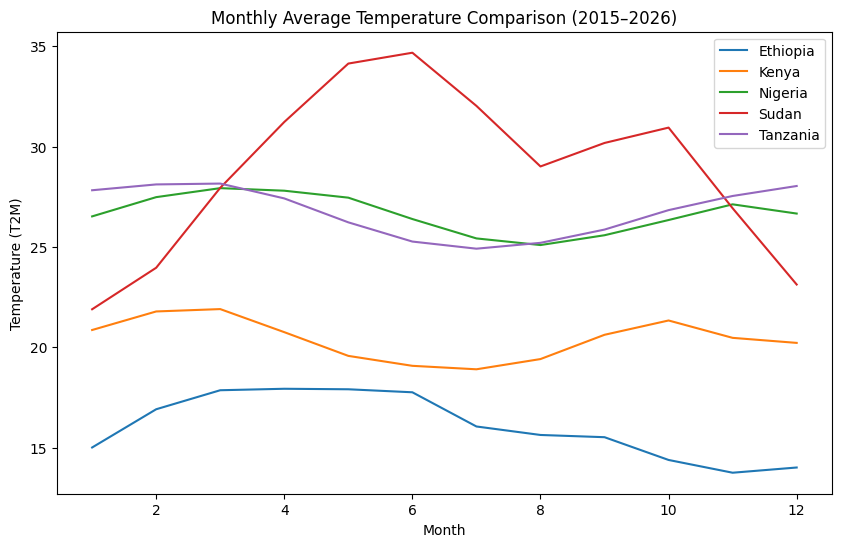

In [22]:
monthly_temp = df_all.groupby(["Country", "Month"])["T2M"].mean().reset_index()
pivot_temp = monthly_temp.pivot(index="Month", columns="Country", values="T2M")
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for country in pivot_temp.columns:
    plt.plot(pivot_temp.index, pivot_temp[country], label=country)

plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

The line chart compares monthly average temperatures across five African countries from 2015 to 2026.

All countries show clear seasonal patterns, with higher temperatures in certain months and lower temperatures in others.

In [11]:
t2m_summary = df_all.groupby("Country")["T2M"].agg(["mean", "median", "std"])
t2m_summary
t2m_summary = t2m_summary.reset_index()
t2m_summary

,Country,mean,median,std
0,Ethiopia,16.068500,16.04,1.898050
1,Kenya,20.427600,20.36,1.440824
2,Nigeria,26.656928,26.82,1.123335
3,Sudan,28.759007,29.16,4.681305
4,Tanzania,26.802422,26.99,1.325388


Precipitation Variability Comparison

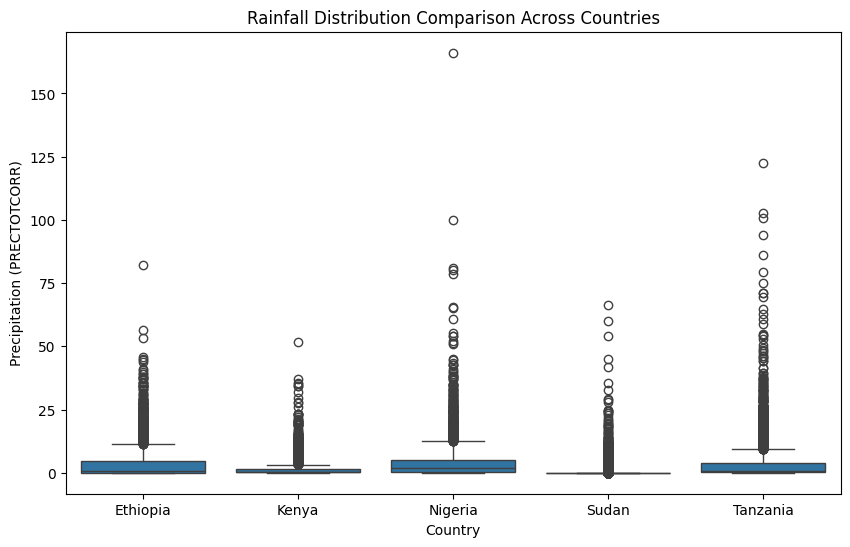

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_all,
    x="Country",
    y="PRECTOTCORR"
)

plt.title("Rainfall Distribution Comparison Across Countries")
plt.xlabel("Country")
plt.ylabel("Precipitation (PRECTOTCORR)")
plt.show()

## Rainfall Distribution Comparison

The boxplot compares precipitation levels across the five countries.



In [13]:
precip_summary = df_all.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


Extreme Event Frequency

In [26]:
extreme_heat = df_all[df_all["T2M_MAX"] > 35]
heat_counts = extreme_heat.groupby(["Country", "YEAR"]).size().reset_index(name="ExtremeHeatDays")
heat_counts

,Country,YEAR,ExtremeHeatDays
0,Sudan,2015,280
1,Sudan,2016,252
2,Sudan,2017,266
3,Sudan,2018,248
4,Sudan,2019,251
5,Sudan,2020,195
6,Sudan,2021,212
7,Sudan,2022,202
8,Sudan,2023,262
9,Sudan,2024,223


In [34]:
df_all["DryDay"] = df_all["PRECTOTCORR"] < 1
df_all = df_all.sort_values(["Country", "DATE"])
df_all["DryGroup"] = (
    df_all["DryDay"] != df_all.groupby("Country")["DryDay"].shift()
).cumsum()
dry_df = df_all[df_all["DryDay"]]
streak_lengths = dry_df.groupby(
    ["Country", "YEAR", "DryGroup"]
).size().reset_index(name="DryStreakLength")
dry_days_per_year = streak_lengths.groupby(
    ["Country", "YEAR"]
)["DryStreakLength"].sum().reset_index()
dry_days_per_year

,Country,YEAR,DryStreakLength
0,Ethiopia,2015,215
1,Ethiopia,2016,176
2,Ethiopia,2017,190
3,Ethiopia,2018,194
4,Ethiopia,2019,186
5,Ethiopia,2020,190
6,Ethiopia,2021,202
7,Ethiopia,2022,208
8,Ethiopia,2023,171
9,Ethiopia,2024,168


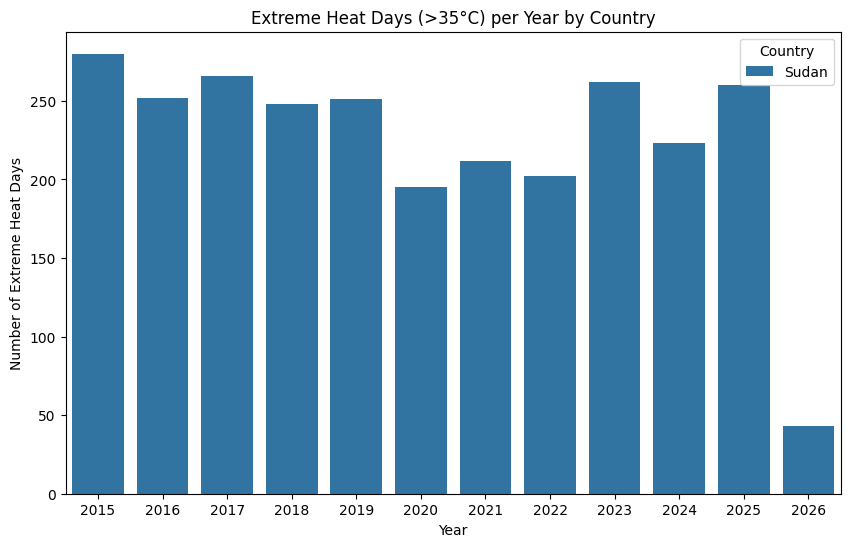

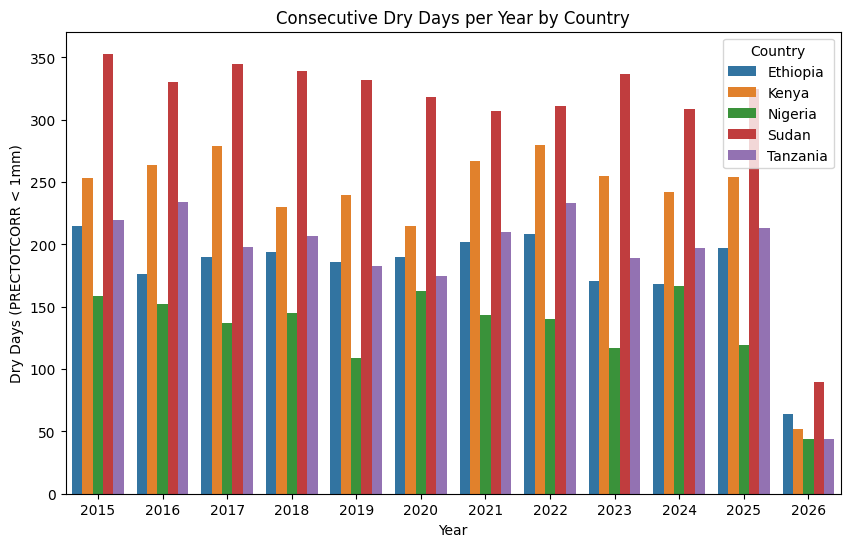

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=heat_counts,
    x="YEAR",
    y="ExtremeHeatDays",
    hue="Country"
)

plt.title("Extreme Heat Days (>35°C) per Year by Country")
plt.xlabel("Year")
plt.ylabel("Number of Extreme Heat Days")
plt.show()


plt.figure(figsize=(10,6))

sns.barplot(
    data=dry_days_per_year,
    x="YEAR",
    y="DryStreakLength",
    hue="Country"
)

plt.title("Consecutive Dry Days per Year by Country")
plt.xlabel("Year")
plt.ylabel("Dry Days (PRECTOTCORR < 1mm)")
plt.show()

Statistical Testing

In [43]:
groups = [
    df_all[df_all["Country"] == "Ethiopia"]["T2M"].dropna(),
    df_all[df_all["Country"] == "Kenya"]["T2M"].dropna(),
    df_all[df_all["Country"] == "Nigeria"]["T2M"].dropna(),
    df_all[df_all["Country"] == "Sudan"]["T2M"].dropna(),
    df_all[df_all["Country"] == "Tanzania"]["T2M"].dropna()
]
from scipy.stats import kruskal

kruskal_result = kruskal(*groups)
kruskal_result


KruskalResult(statistic=np.float64(15392.992231563152), pvalue=np.float64(0.0))

The results show a test statistic of approximately 15392.99 and a p-value reported as 0.0 (i.e., extremely close to zero).

This indicates that there are highly significant differences in temperature distributions across the countries.Climate varies significantly across regions.

Vulnerability Ranking & Key Observations

In [70]:
summary = df_all.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "std"
}).rename(columns={
    "T2M": "Temp",
    "PRECTOTCORR": "Rain_Variability"
}).reset_index()

summary

heat = df_all[df_all["T2M_MAX"] > 35] \
    .groupby("Country") \
    .size() \
    .reset_index(name="ExtremeHeatDays")

summary = summary.merge(heat, on="Country", how="left")

# Fill missing values
summary["ExtremeHeatDays"] = summary["ExtremeHeatDays"].fillna(0)
dry = dry_days_per_year.groupby("Country")["DryStreakLength"] \
    .mean() \
    .reset_index()

dry = dry.rename(columns={"DryStreakLength": "DryDays"})

summary = summary.merge(dry, on="Country", how="left")
summary
summary_norm = summary.copy()

for col in ["Temp", "ExtremeHeatDays", "DryDays", "Rain_Variability"]:
    summary_norm[col] = (
        (summary[col] - summary[col].min()) /
        (summary[col].max() - summary[col].min())
        
    )
    summary_norm["VulnerabilityScore"] = (
    0.2 * summary_norm["Temp"] +
    0.4 * summary_norm["ExtremeHeatDays"] +
    0.3 * summary_norm["DryDays"] +
    0.1 * summary_norm["Rain_Variability"]
)
    ranking = summary_norm.sort_values("VulnerabilityScore", ascending=False)
ranking

,Country,Temp,Rain_Variability,ExtremeHeatDays,DryDays,VulnerabilityScore
3,Sudan,1.000000,0.000000,1.0,1.000000,0.900000
4,Tanzania,0.845823,1.000000,0.0,0.336982,0.370259
2,Nigeria,0.834358,0.850958,0.0,0.000000,0.251967
1,Kenya,0.343493,0.024777,0.0,0.588291,0.247664
0,Ethiopia,0.000000,0.653297,0.0,0.269396,0.146148


In [ ]:
import numpy as np

def compute_slope(group):
    x = group["YEAR"]
    y = group["T2M"]
    
    slope, _ = np.polyfit(x, y, 1)  
    return slope

warming_trend = df_all.groupby("Country").apply(compute_slope).reset_index(name="WarmingRate")

warming_trend

,Country,WarmingRate
0,Ethiopia,0.028496
1,Kenya,0.007463
2,Nigeria,0.058531
3,Sudan,-0.076895
4,Tanzania,0.024032
